In [4]:
# -*- coding: utf-8 -*-
"""
Created on Wed Oct 21 10:51:32 2020

@author: cheritie
"""

import time

import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.MisRegistration import MisRegistration
from OOPAO.ShackHartmann import ShackHartmann
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.Zernike import Zernike
from OOPAO.calibration.CalibrationVault import CalibrationVault
from OOPAO.calibration.InteractionMatrix import InteractionMatrix
from OOPAO.tools.displayTools import cl_plot, displayMap
# %% -----------------------     read parameter file   ----------------------------------
from tutorials.scao_system.parameter_files.parameterFile_VLT_I_Band_SHWFS import initializeParameterFile

param = initializeParameterFile()




     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2
Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       8.0    4629306.6 
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%

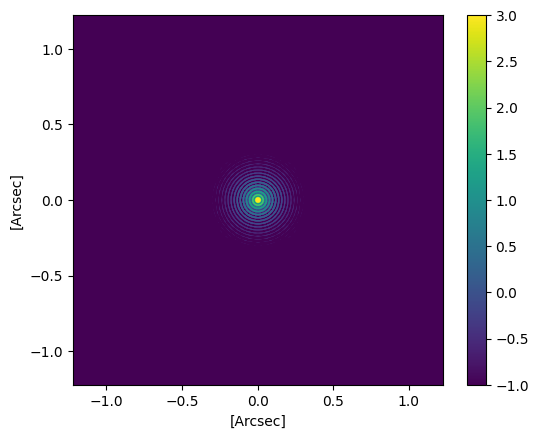

In [5]:

# %%
plt.ion()

#%% -----------------------     TELESCOPE   ----------------------------------

# create the Telescope object
tel = Telescope(resolution          = param['resolution'],\
                diameter            = param['diameter'],\
                samplingTime        = param['samplingTime'],\
                centralObstruction  = param['centralObstruction'],display_optical_path=True)

#%% -----------------------     NGS   ----------------------------------
# create the Source object
ngs=Source(optBand   = param['opticalBand'],\
           magnitude = param['magnitude'])

# combine the NGS to the telescope using '*' operator:
ngs*tel

tel.computePSF(zeroPaddingFactor = 6)
plt.figure()
plt.imshow(np.log10(np.abs(tel.PSF)),extent = [tel.xPSF_arcsec[0],tel.xPSF_arcsec[1],tel.xPSF_arcsec[0],tel.xPSF_arcsec[1]])
plt.clim([-1,3])
plt.xlabel('[Arcsec]')
plt.ylabel('[Arcsec]')
plt.colorbar()


src = Source(optBand   = 'K',\
           magnitude = param['magnitude'])

# combine the NGS to the telescope using '*' operator:
# src*tel


-> Computing the initial phase screen...
initial phase screen : 0.0166623592376709 s
ZZt.. : 2.9959487915039062 s
ZXt.. : 0.3105621337890625 s
XXt.. : 0.1561737060546875 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.009576797485351562 s
ZZt.. : 1.430511474609375e-06 s
ZXt.. : 2.9802322387695312e-05 s
XXt.. : 8.821487426757812e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.00927734375 s
ZZt.. : 3.814697265625e-06 s
ZXt.. : 3.981590270996094e-05 s
XXt.. : 2.7894973754882812e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.009511947631835938 s
ZZt.. : 2.6226043701171875e-06 s
ZXt.. : 3.3855438232421875e-05 s
XXt.. : 8.344650268554688e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase scree

Text(0.5, 1.0, 'DM Actuator Coordinates')

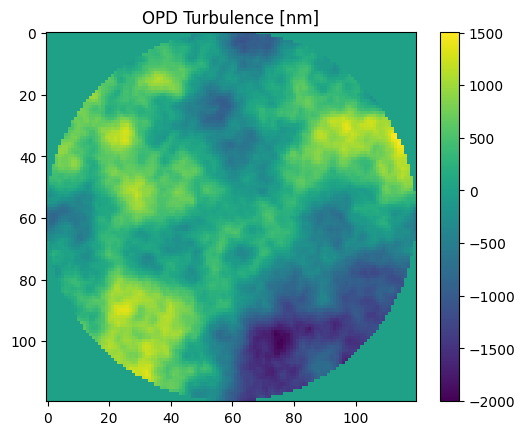

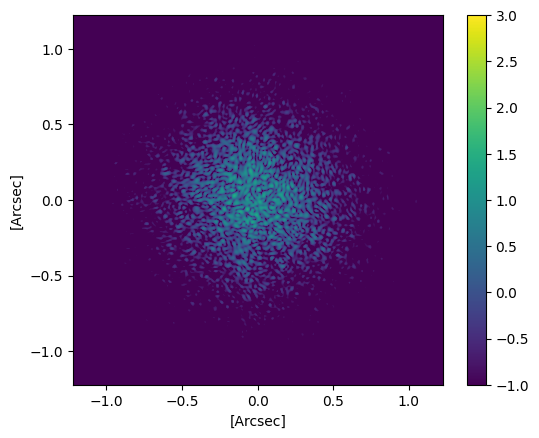

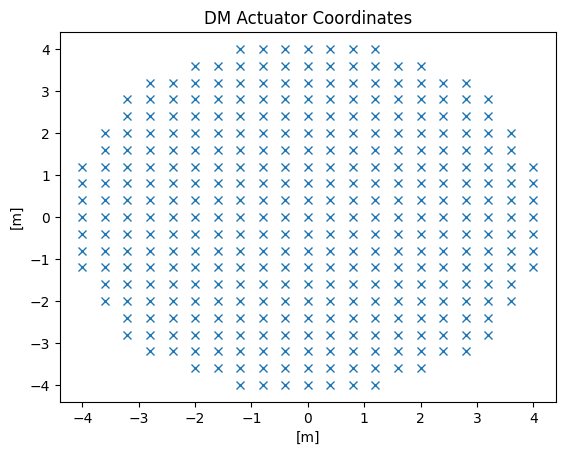

In [6]:
#%% -----------------------     ATMOSPHERE   ----------------------------------

# create the Atmosphere object
atm=Atmosphere(telescope     = tel,\
               r0            = param['r0'],\
               L0            = param['L0'],\
               windSpeed     = param['windSpeed'],\
               fractionalR0  = param['fractionnalR0'],\
               windDirection = param['windDirection'],\
               altitude      = param['altitude'])
# initialize atmosphere
atm.initializeAtmosphere(tel)

atm.update()

plt.figure()
plt.imshow(atm.OPD*1e9)
plt.title('OPD Turbulence [nm]')
plt.colorbar()


tel+atm
tel.computePSF(8)
plt.figure()
plt.imshow((np.log10(tel.PSF)),extent = [tel.xPSF_arcsec[0],tel.xPSF_arcsec[1],tel.xPSF_arcsec[0],tel.xPSF_arcsec[1]])
plt.clim([-1,3])

plt.xlabel('[Arcsec]')
plt.ylabel('[Arcsec]')
plt.colorbar()

#%% -----------------------     DEFORMABLE MIRROR   ----------------------------------
# mis-registrations object
misReg = MisRegistration(param)
# if no coordonates specified, create a cartesian dm
dm=DeformableMirror(telescope    = tel,\
                    nSubap       = param['nSubaperture'],\
                    mechCoupling = param['mechanicalCoupling'],\
                    misReg       = misReg)

plt.figure()
plt.plot(dm.coordinates[:,0],dm.coordinates[:,1],'x')
plt.xlabel('[m]')
plt.ylabel('[m]')
plt.title('DM Actuator Coordinates')



Selecting valid subapertures based on flux considerations..
NGS(I) ~~> telescope ~~> shackHartmann
NGS(I) ~~> telescope ~~> shackHartmann


Text(0.5, 1.0, 'WFS Camera Frame - With Noise')

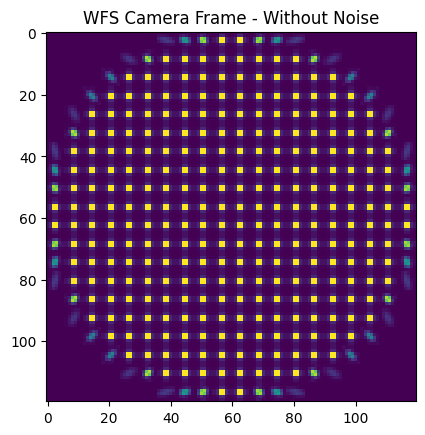

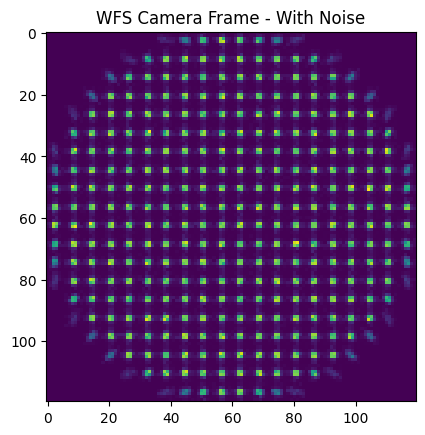

In [7]:
#%% -----------------------     SH WFS   ----------------------------------

# make sure tel and atm are separated to initialize the PWFS
tel-atm
tel.resetOPD()
wfs = ShackHartmann(nSubap          = param['nSubaperture'],\
              telescope             = tel,\
              lightRatio            = param['lightThreshold'],\
              binning_factor=1,\
              is_geometric = False, shannon_sampling=True)



#%
wfs.cam.photonNoise = False

tel*wfs
plt.close('all')
plt.figure()
plt.imshow(wfs.cam.frame)
plt.title('WFS Camera Frame - Without Noise')

wfs.cam.photonNoise = True
tel*wfs
plt.figure()
plt.imshow(wfs.cam.frame)
plt.title('WFS Camera Frame - With Noise')


In [12]:
#%% -----------------------     Modal Basis   ----------------------------------
# compute the modal basis
from OOPAO.calibration.compute_KL_modal_basis import compute_KL_basis
from OOPAO.calibration.ao_calibration import ao_calibration
# M2C_KL = compute_KL_basis(tel,atm,dm)
# # foldername_M2C  = None  # name of the folder to save the M2C matrix, if None a default name is used 
# # filename_M2C    = None  # name of the filename, if None a default name is used 
# # # KL Modal basis
# M2C_KL = compute_M2C(telescope            = tel,\
#                                  atmosphere         = atm,\
#                                  deformableMirror   = dm,\
#                                  param              = param,\
#                                  nameFolder         = None,\
#                                  nameFile           = None,\
#                                  remove_piston      = True,\
#                                  HHtName            = None,\
#                                  baseName           = None ,\
#                                  mem_available      = 8.1e9,\
#                                  minimF             = False,\
#                                  nmo                = 300,\
#                                  ortho_spm          = True,\
#                                  SZ                 = np.int(2*tel.OPD.shape[0]),\
#                                  nZer               = 3,\
#                                  NDIVL              = 1)
#
ao_calib =  ao_calibration(param            = param,\
                           ngs              = ngs,\
                           tel              = tel,\
                           atm              = atm,\
                           dm               = dm,\
                           wfs              = wfs,\
                           nameFolderIntMat = None,\
                           nameIntMat       = None,\
                           nameFolderBasis  = None,\
                           nameBasis        = None,\
                           nMeasurements    = 100)

#%% ZERNIKE Polynomials
# create Zernike Object
Z = Zernike(tel,300)
# compute polynomials for given telescope
Z.computeZernike(tel)

# mode to command matrix to project Zernike Polynomials on DM
M2C_zernike = np.linalg.pinv(np.squeeze(dm.modes[tel.pupilLogical,:]))@Z.modes

# show the first 10 zernikes
dm.coefs = M2C_zernike[:,:10]
tel*dm
displayMap(tel.OPD)

#%% to manually measure the interaction matrix

# amplitude of the modes in m
stroke=1e-9
# Modal Interaction Matrix

#%%
wfs.is_geometric = True

M2C_zonal = np.eye(dm.nValidAct)
# zonal interaction matrix
calib_zonal = InteractionMatrix(  ngs            = ngs,\
                            atm            = atm,\
                            tel            = tel,\
                            dm             = dm,\
                            wfs            = wfs,\
                            M2C            = M2C_zonal,\
                            stroke         = stroke,\
                            nMeasurements  = 100,\
                            noise          = 'off')

plt.figure()
plt.plot(np.std(calib_zonal.D,axis=0))
plt.xlabel('Mode Number')
plt.ylabel('WFS slopes STD')

#%%
# Modal interaction matrix

# Modal interaction matrix
calib_zernike = CalibrationVault(calib_zonal.D@M2C_zernike)

plt.figure()
plt.plot(np.std(calib_zernike.D,axis=0))
plt.xlabel('Mode Number')
plt.ylabel('WFS slopes STD')

#%% switch to a diffractive SH-WFS

wfs.is_geometric = False

#%%
tel.resetOPD()
# initialize DM commands
dm.coefs=0
ngs*tel*dm*wfs
tel+atm

# dm.coefs[100] = -1

tel.computePSF(4)
plt.close('all')
    
# These are the calibration data used to close the loop
calib_CL    = calib_zernike
M2C_CL      = M2C_zernike


# combine telescope with atmosphere
tel+atm

# initialize DM commands
dm.coefs=0
ngs*tel*dm*wfs


plt.show()



Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_I_band_20x20/zonal_interaction_matrix_120_res_332_subap_diffractive...
ERROR: No file found! computing imat..
Interaction Matrix Computation:


  0%|          | 0/4 [00:00<?, ?it/s]

NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann


 25%|██▌       | 1/4 [00:03<00:09,  3.29s/it]

100/357
Time elapsed: 3.294295310974121 s
NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann


...

 75%|███████▌  | 3/4 [00:02<00:00,  1.28it/s]

NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann
300/357
Time elapsed: 0.8282797336578369 s
NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann


100%|██████████| 4/4 [00:02<00:00,  1.44it/s]

NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann
400/357
Time elapsed: 0.4652140140533447 s


Re-initializing WFS...
NGS(I) ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(I) ~~> atmosphere ~~> telescope ~~> deformableMirror ~~> shackHartmann


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


NGS(I) ~~> atmosphere ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(K) ~~> atmosphere ~~> telescope ~~> deformableMirror
Elapsed time: 0.09456825256347656 s


/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO/OOPAO/tools/displayTools.py:490: UserWarning: Attempting to set identical left == right == 0.0 results in singular transformations; automatically expanding.
  im_tmp.axes.set_xlim([np.min(data[0])-0.1*np.abs(np.min(data[0])),np.max(data[0])+0.1*np.abs(np.max(data[0]))])
/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO/OOPAO/tools/displayTools.py:493: UserWarning: Attempting to set identical bottom == top == 0.0 results in singular transformations; automatically expanding.
  im_tmp.axes.set_ylim([np.min(data[1])-0.1*np.abs(np.min(data[1])),np.max(data[1])+0.1*np.abs(np.max(data[1]))])


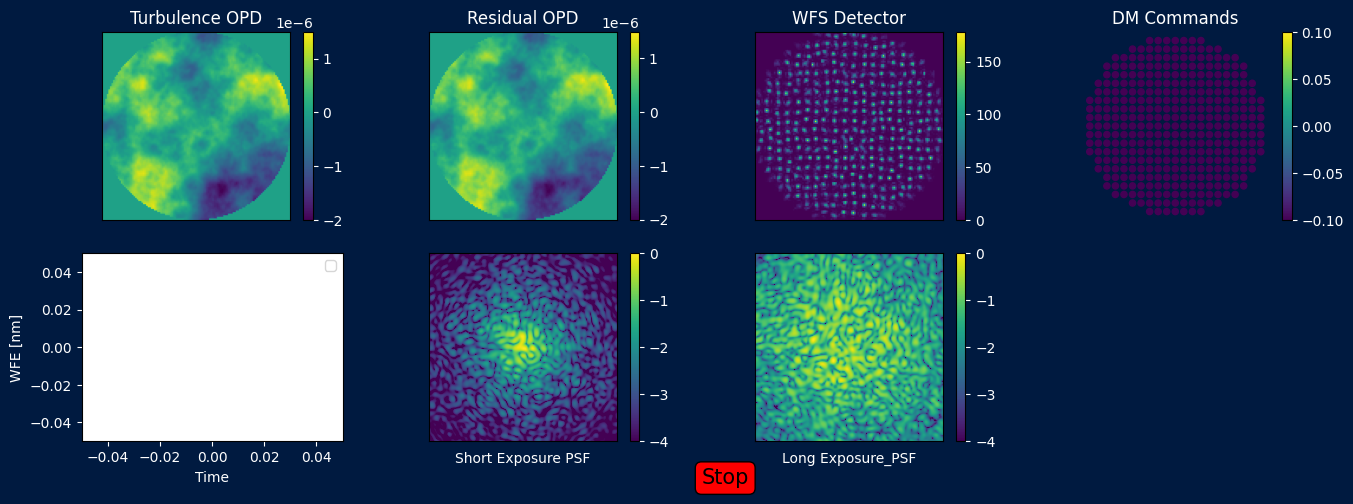

Loop0/200 Turbulence: 663.270989389561 -- Residual:663.270989389561

NGS(I) ~~> atmosphere ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(K) ~~> atmosphere ~~> telescope ~~> deformableMirror
Elapsed time: 0.0753927230834961 s


<Figure size 640x480 with 0 Axes>

Loop1/200 Turbulence: 664.4645111096315 -- Residual:664.4645111096315

NGS(I) ~~> atmosphere ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(K) ~~> atmosphere ~~> telescope ~~> deformableMirror
Elapsed time: 0.07622218132019043 s


<Figure size 640x480 with 0 Axes>

Loop2/200 Turbulence: 665.6556443707079 -- Residual:413.7638577558501

NGS(I) ~~> atmosphere ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(K) ~~> atmosphere ~~> telescope ~~> deformableMirror
Elapsed time: 0.08382892608642578 s


...

<Figure size 640x480 with 0 Axes>

Loop198/200 Turbulence: 581.4442355627392 -- Residual:124.83117616241496

NGS(I) ~~> atmosphere ~~> telescope ~~> deformableMirror ~~> shackHartmann
NGS(K) ~~> atmosphere ~~> telescope ~~> deformableMirror
Elapsed time: 0.07201790809631348 s


<Figure size 640x480 with 0 Axes>

Loop199/200 Turbulence: 580.614905863799 -- Residual:122.27021035741076



Text(0, 0.5, 'WFE [nm]')

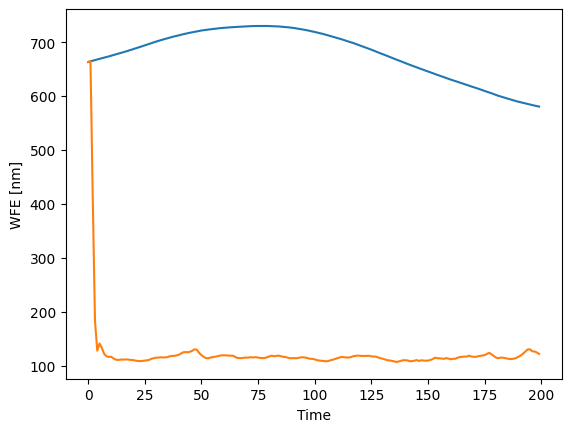

In [13]:
param['nLoop'] = 200
# allocate memory to save data
SR                      = np.zeros(param['nLoop'])
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
SE_PSF = []
LE_PSF = np.log10(tel.PSF_norma_zoom)

plot_obj = cl_plot(list_fig          = [atm.OPD,tel.mean_removed_OPD,wfs.cam.frame,[dm.coordinates[:,0],np.flip(dm.coordinates[:,1]),dm.coefs],[[0,0],[0,0]],np.log10(tel.PSF_norma_zoom),np.log10(tel.PSF_norma_zoom)],\
                   type_fig          = ['imshow','imshow','imshow','scatter','plot','imshow','imshow'],\
                   list_title        = ['Turbulence OPD','Residual OPD','WFS Detector','DM Commands',None,None,None],\
                   list_lim          = [None,None,None,None,None,[-4,0],[-4,0]],\
                   list_label        = [None,None,None,None,['Time','WFE [nm]'],['Short Exposure PSF',''],['Long Exposure_PSF','']],\
                   n_subplot         = [4,2],\
                   list_display_axis = [None,None,None,None,True,None,None],\
                   list_ratio        = [[0.95,0.95,0.1],[1,1,1,1]], s=20)
# loop parameters
gainCL                  = 0.4
wfs.cam.photonNoise     = True
display                 = True

reconstructor = M2C_CL@calib_CL.M

for i in range(param['nLoop']):
    a=time.time()
    # update phase screens => overwrite tel.OPD and consequently tel.src.phase
    atm.update()
    # save phase variance
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    # save turbulent phase
    turbPhase = tel.src.phase
    # propagate to the WFS with the CL commands applied
    ngs*tel*dm*wfs
    src*tel
    tel.print_optical_path()
    dm.coefs=dm.coefs-gainCL*np.matmul(reconstructor,wfsSignal)
    # store the slopes after computing the commands => 2 frames delay
    wfsSignal=wfs.signal
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')
    # update displays if required
    if display==True:        
        tel.computePSF(4)
        if i>15:
            SE_PSF.append(np.log10(tel.PSF_norma_zoom))
            LE_PSF = np.mean(SE_PSF, axis=0)
        
        cl_plot(list_fig   = [atm.OPD,tel.mean_removed_OPD,wfs.cam.frame,dm.coefs,[np.arange(i+1),residual[:i+1]],np.log10(tel.PSF_norma_zoom), LE_PSF],
                               plt_obj = plot_obj)
        plt.pause(0.1)
        if plot_obj.keep_going is False:
            break
    
    SR[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    OPD=tel.OPD[np.where(tel.pupil>0)]

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')

#%%
plt.figure()
plt.plot(total)
plt.plot(residual)
plt.xlabel('Time')
plt.ylabel('WFE [nm]')
